In [481]:
# %% Import libraries
from scipy.io import savemat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mesa.features import stft, stft_labels
from mesa.visualization import plot_signal, dual_plot, spectrogram
import librosa
from airPLS import airPLS


In [482]:
# % Read data
F_data = pd.read_csv("../../data/GC-FID/Y_data.csv", header=None)
F_data_matrix = F_data.to_numpy()

idx = np.where(np.sum(F_data_matrix, axis=1)==0)
idx_blank_24h = [0,1,2,3]
idx_blank_72h = [52, 53, 54, 55]
df = pd.read_csv("../../data/GC-FID/X_data.csv", header=None)
X = df.to_numpy().T

print(X.shape)
X = np.delete(X, idx, axis=0)
F_data_matrix = np.delete(F_data_matrix, idx, axis=0)
print(X.shape)

(104, 45001)
(96, 45001)


Reducing the baseline seems to take away the effect of factor time. Perhaps the main difference between them is precisely the different baselines

In [483]:
# %% Baseline reduction using airPLS
if False:
    print("Removing baseline...")
    for sample_id in range(X.shape[0]):
        correction = airPLS(X[sample_id])
        X[sample_id] -= correction

In [484]:
# STFT params
sr = 200
window_length = 45001 // 1
n_fft = window_length // 10
# n_fft = 128
hop = window_length//1
window = "boxcar"
center = False

D = stft(X,window_length,hop, window=window, center=center, n_fft = n_fft)
# Sxx = np.abs(D)**2
# Sxx = np.real(D)
Sxx = D
# Sxx = librosa.amplitude_to_db(np.abs(D))


times, freqs = stft_labels(D, sr, hop, n_fft = n_fft)

print(f"Sxx.shape: {Sxx.shape}")

Sxx.shape: (96, 2251, 1)


### Numpy FFT
Check the equivalence if the size of the window in the STFT is just as large as the signal

In [485]:
if window_length == 45001:
    Sxx_fft = (np.fft.fft(X, n = n_fft)[:,0:n_fft//2+1])
    Sxx_fft = Sxx_fft[:,:,np.newaxis]
    print((Sxx == Sxx_fft).all())
    print(np.isclose(Sxx, Sxx_fft).all())
Sxx = Sxx_fft

False
False


In [486]:
### Eliminate filtered frequencies
mask = np.ones(len(freqs), dtype=bool)

mask[freqs >  5.0] = False
mask[freqs <  0.0] = False
# id_50Hz = np.argmin(np.abs(freqs - 50.0))
# mask[id_50Hz] = False


freqs = freqs[mask]
Sxx = Sxx[:, mask, :]
n_frequencies = len(freqs)
print(f"Nº of frequencies after  masking the filter: {n_frequencies}")

Nº of frequencies after  masking the filter: 113


#### Removing blanks for proper comparability

In [487]:
# blank_24h = Sxx[idx_blank_24h]
# blank_72h = Sxx[idx_blank_72h]

idx_24h = np.where(F_data_matrix[:, 0] == 1)[0]
idx_72h = np.where(F_data_matrix[:, 0] == 2)[0]

# Arificial slip for testing
# slip = 0
# idx_blank_24h = np.array(idx_blank_24h) + slip
# idx_blank_72h = np.array(idx_blank_72h) + slip

# idx_24h = np.array(idx_24h) + slip
# idx_72h = np.array(idx_72h) + slip

# Averages across freqs before removing baseline
A24h = np.mean(Sxx[idx_24h], axis = 0)
A72h = np.mean(Sxx[idx_72h], axis = 0)  

# Blanks
B1 = np.mean(Sxx[idx_blank_24h], axis = 0)
B2 = np.mean(Sxx[idx_blank_72h], axis = 0)

Sxx[idx_24h] -= B1
Sxx[idx_72h] -= B2

# Averages across freqs after removing baseline
AB24h = np.mean(Sxx[idx_24h], axis = 0)
AB72h = np.mean(Sxx[idx_72h], axis = 0)

# Sxx = np.delete(Sxx, idx, axis=0)

Sxx.shape

(96, 113, 1)

In [488]:
idx_24h, idx_72h

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]),
 array([48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64,
        65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81,
        82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]))

In [489]:
A24h.shape

(113, 1)

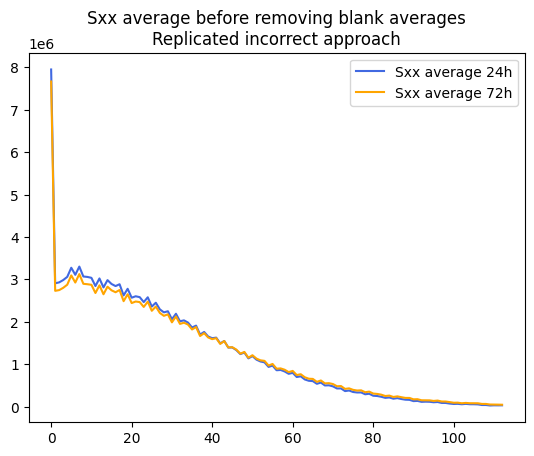

In [490]:
plt.plot(np.abs(A24h), label ="Sxx average 24h", color="royalblue");
plt.plot(np.abs(A72h), label ="Sxx average 72h", color = "orange");
plt.legend()
plt.title("Sxx average before removing blank averages\nReplicated incorrect approach");

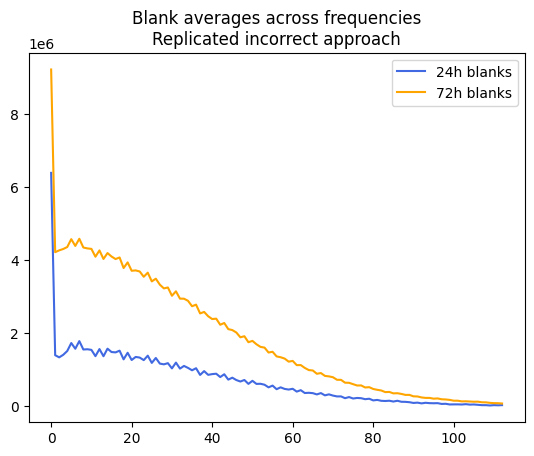

In [491]:
plt.plot(np.abs(B1), label ="24h blanks", color="royalblue");
plt.plot(np.abs(B2), label ="72h blanks", color="orange");
plt.legend()
plt.title("Blank averages across frequencies\nReplicated incorrect approach");

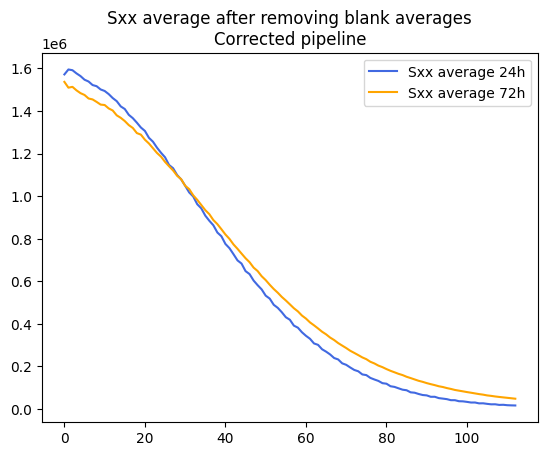

In [ ]:
# B2 = np.mean(Sxx[idx_blank_72h], axis = 0)
plt.plot(np.abs(AB24h), label ="Sxx average 24h", color="royalblue");
plt.plot(np.abs(AB72h), label ="Sxx average 72h", color="orange");
plt.legend()
plt.title("Sxx average after removing blank averages\nReplicated incorrect approach");

In [493]:
# %% Unfolding
from mesa.fusion import unfold_2D
subjects = np.arange(96)+1
labels = [subjects, freqs, times]
label_names = ["subjects", "freq", "time"]
X_unfold, labels_unfold, label_names = unfold_2D(Sxx,rows=[0], cols=[1,2],
                                                 labels=labels, label_names=label_names)

In [494]:
X_peak = pd.read_csv("../../data/GC-FID/X_peak.csv", header=None)
F_peak = pd.read_csv("../../data/GC-FID/Y_peak.csv", header=None)
F_data = pd.read_csv("../../data/GC-FID/Y_data.csv", header=None)
F_data = np.delete(F_data.to_numpy(), idx, axis = 0)

In [ ]:
from scipy.io import savemat

savemat(
    "GC-FID.mat", {"data": X_unfold,
                    "label_names": np.array(label_names, dtype=object),
                    "obs_l": np.array(labels_unfold[0],  dtype=object),
                    "var_l": np.array(labels_unfold[1],  dtype=object),
                    "X_peak": X_peak,
                    "F_peak": F_peak,
                    "F_data": F_data}
)